In [ ]:
import kagglehub
import os
import pandas as pd
from sklearn.preprocessing import StandardScaler

# ---------------------------------------------------------
# 1. DOWNLOAD AND LOAD THE DATA
# ---------------------------------------------------------
print("Downloading dataset from Kaggle...")
path = kagglehub.dataset_download("jayjoshi37/ev-charging-station-usage-and-grid-load-analysis")

# Find the CSV file inside the hidden downloaded folder
csv_file = [f for f in os.listdir(path) if f.endswith('.csv')][0]
full_file_path = os.path.join(path, csv_file)

# Load the data into a Pandas DataFrame
df = pd.read_csv(full_file_path)

# ---------------------------------------------------------
# 2. DATA UNDERSTANDING, STATISTICS & DUPLICATES
# ---------------------------------------------------------
print("\n--- A. Dataset Info ---")
print(df.info())

print("\n--- B. Missing Values Check ---")
print(df.isnull().sum())

print("\n--- C. Duplicate Check ---")
duplicate_count = df.duplicated().sum()
print(f"Total duplicate rows found: {duplicate_count}")
if duplicate_count > 0:
    df = df.drop_duplicates()
    print("Action: Duplicates have been removed.")
else:
    print("Action: No duplicates to remove.")

print("\n--- D. Basic Statistics (Pre-Scaling) ---")
print(df.describe().round(2))

# ---------------------------------------------------------
# 3. FEATURE ENGINEERING
# ---------------------------------------------------------
# Convert date_time string to actual datetime objects
df['date_time'] = pd.to_datetime(df['date_time'])

# Extract useful time-based numerical features
df['hour_of_day'] = df['date_time'].dt.hour
df['day_of_week'] = df['date_time'].dt.dayofweek # Monday=0, Sunday=6

# Drop the original date_time column as models cannot read it
df = df.drop(columns=['date_time'])

# ---------------------------------------------------------
# 4. ENCODING CATEGORICAL VARIABLES
# ---------------------------------------------------------
# One-Hot Encoding (Guarantees binary 0/1 integer columns instead of True/False)
df = pd.get_dummies(df, columns=['station_type', 'city_zone'], drop_first=True, dtype=int)

# Explicit Ordinal Mapping for the Target Variable (Viva-proof!)
risk_mapping = {'Low': 0, 'Medium': 1, 'High': 2}
df['peak_load_risk_encoded'] = df['peak_load_risk'].map(risk_mapping)

print("\n--- Target Variable Mapping (Ordinal) ---")
for text_label, num_label in risk_mapping.items():
    print(f"{text_label} -> {num_label}")

# Drop the original text target column
df = df.drop(columns=['peak_load_risk'])

# ---------------------------------------------------------
# 5. SCALING NUMERICAL VARIABLES
# ---------------------------------------------------------
scaler = StandardScaler()
num_cols = ['energy_dispensed_kwh', 'avg_charging_duration_minutes', 
            'grid_load_mw', 'vehicles_charged', 'renewable_energy_used_percent']

# Transform continuous variables so they have a mean of 0 and std deviation of 1
df[num_cols] = scaler.fit_transform(df[num_cols])

# ---------------------------------------------------------
# 6. FINAL OUTPUTS FOR REPORT
# ---------------------------------------------------------
print("\n--- Preprocessing Complete! ---")
print(f"\nDataset Shape After Preprocessing: {df.shape}")

print("\n--- Final Feature Names ---")
print(df.columns.tolist())

print("\nFirst 5 Rows of Cleaned Data:")
print(df.head())

--- 1. Correlation Matrix (Similarity) ---


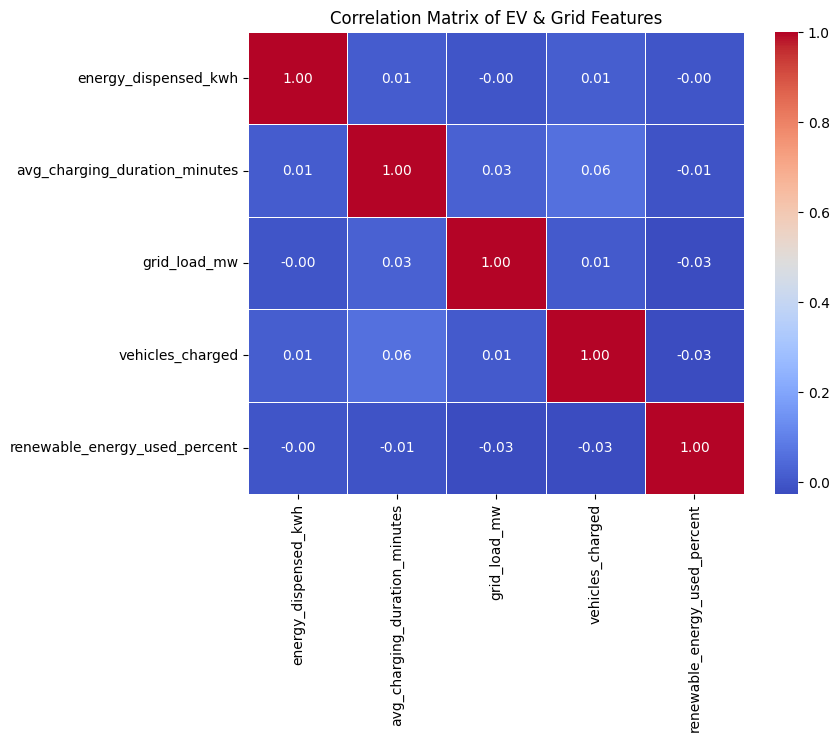


--- 2. Euclidean Distance (Dissimilarity between City Zones) ---


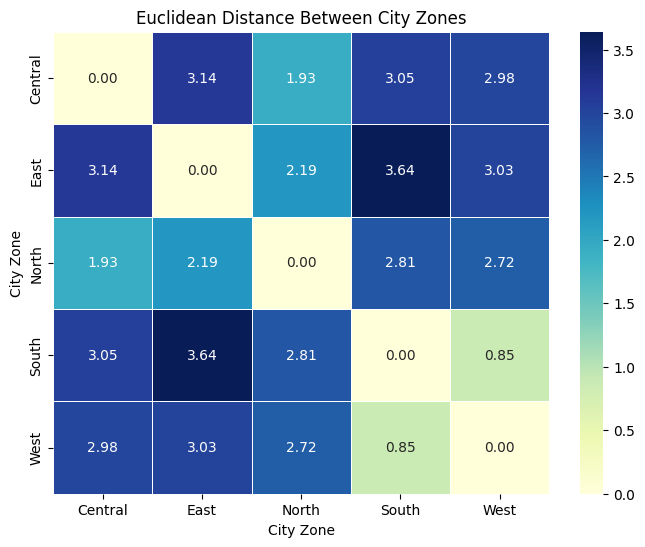

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import euclidean_distances
from sklearn.preprocessing import StandardScaler
import pandas as pd

# ---------------------------------------------------------
# 1. MEASURE OF SIMILARITY: Correlation Matrix
# ---------------------------------------------------------
print("--- 1. Correlation Matrix (Similarity) ---")

# Calculate Pearson correlation on the already-scaled numerical columns from Step 5
corr_matrix = df[num_cols].corr()

# Plotting the Similarity Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix of EV & Grid Features')
plt.show()

# ---------------------------------------------------------
# 2. MEASURE OF DISSIMILARITY: Euclidean Distance
# ---------------------------------------------------------
print("\n--- 2. Euclidean Distance (Dissimilarity between City Zones) ---")

# Load the raw data temporarily to group by the original text names
df_raw = pd.read_csv(full_file_path)

# Group by 'city_zone' and calculate the mean for our key metrics
zone_profiles = df_raw.groupby('city_zone')[
    ['energy_dispensed_kwh', 'grid_load_mw', 'vehicles_charged']
].mean()

# rigorously scale the grouped profiles before calculating distance
scaler_dist = StandardScaler()
zone_scaled = pd.DataFrame(
    scaler_dist.fit_transform(zone_profiles),
    index=zone_profiles.index,
    columns=zone_profiles.columns
)

# Calculate Euclidean distance on the standardized profiles
dist_matrix = euclidean_distances(zone_scaled)

# Convert the resulting matrix into a Pandas DataFrame using the zone names as labels
dist_df = pd.DataFrame(dist_matrix, index=zone_profiles.index, columns=zone_profiles.index)

# Plotting the Dissimilarity Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(dist_df, annot=True, cmap='YlGnBu', linewidths=0.5, fmt='.2f')
plt.title("Euclidean Distance Between City Zones")
plt.xlabel("City Zone")
plt.ylabel("City Zone")
plt.show()